In [1]:
!pip install pandas numpy matplotlib scikit-learn xgboost torch statsmodels

In [2]:
import zipfile
import os

zip_path = r"E:\MY projects\Flash Flood Prediction Project\data\rainfall_monthly.zip"
extract_path = r"E:\MY projects\Flash Flood Prediction Project\data\rainfall_monthly"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [3]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU not available - using CPU")
    device = torch.device("cpu")

print("Using device:", device)

PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Using device: cuda


In [4]:
import glob

csv_files = glob.glob(
    os.path.join(extract_path, "**", "*.csv"),
    recursive=True
)

print("Number of CSV files:", len(csv_files))
print(csv_files[:5])

Number of CSV files: 80
['E:\\MY projects\\Flash Flood Prediction Project\\data\\rainfall_monthly\\rainfall_monthly\\rainfall_2020_01.csv', 'E:\\MY projects\\Flash Flood Prediction Project\\data\\rainfall_monthly\\rainfall_monthly\\rainfall_2020_02.csv', 'E:\\MY projects\\Flash Flood Prediction Project\\data\\rainfall_monthly\\rainfall_monthly\\rainfall_2020_03.csv', 'E:\\MY projects\\Flash Flood Prediction Project\\data\\rainfall_monthly\\rainfall_monthly\\rainfall_2020_04.csv', 'E:\\MY projects\\Flash Flood Prediction Project\\data\\rainfall_monthly\\rainfall_monthly\\rainfall_2020_05.csv']


In [6]:
import pandas as pd
data_list = []

for file in csv_files:
    temp = pd.read_csv(file)
    data_list.append(temp)

rainfall_df = pd.concat(data_list, ignore_index=True)

print("Shape:", rainfall_df.shape)
print(rainfall_df.head())
print(rainfall_df.tail())

Shape: (116843, 4)
              datetime  rainfall_mm_per_hour  year  month
0  2020-01-01 00:00:00              0.186617  2020      1
1  2020-01-01 00:30:00              0.000000  2020      1
2  2020-01-01 01:00:00              0.000000  2020      1
3  2020-01-01 01:30:00              0.000000  2020      1
4  2020-01-01 02:00:00              0.000000  2020      1
                   datetime  rainfall_mm_per_hour  year  month
116838  2026-08-31 09:30:00              0.756054  2026      8
116839  2026-08-31 10:00:00              0.803127  2026      8
116840  2026-08-31 10:30:00              0.727114  2026      8
116841  2026-08-31 11:00:00              0.563356  2026      8
116842  2026-08-31 11:30:00              0.368644  2026      8


In [9]:
import numpy as np
rainfall_df["datetime"] = pd.to_datetime(
    rainfall_df["datetime"],
    errors="coerce"
)

rainfall_df["rainfall_mm_per_hour"] = pd.to_numeric(
    rainfall_df["rainfall_mm_per_hour"],
    errors="coerce"
)

# Remove invalid rows
rainfall_df = rainfall_df.dropna(
    subset=["datetime", "rainfall_mm_per_hour"]
)

# Remove infinite values
rainfall_df = rainfall_df[
    np.isfinite(rainfall_df["rainfall_mm_per_hour"])
]

# Rainfall cannot be negative
rainfall_df["rainfall_mm_per_hour"] = rainfall_df[
    "rainfall_mm_per_hour"
].clip(lower=0)

# Remove duplicate timestamps
rainfall_df = rainfall_df.drop_duplicates(
    subset=["datetime"]
)

# Sort chronologically
rainfall_df = rainfall_df.sort_values("datetime")

rainfall_df = rainfall_df.reset_index(drop=True)

print(rainfall_df.info())
print(rainfall_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 116843 entries, 0 to 116842
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   datetime              116843 non-null  datetime64[us]
 1   rainfall_mm_per_hour  116843 non-null  float64       
 2   year                  116843 non-null  int64         
 3   month                 116843 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 3.6 MB
None
                         datetime  rainfall_mm_per_hour           year  \
count                      116843         116843.000000  116843.000000   
mean   2023-05-02 02:32:15.628150              0.175086    2022.847873   
min           2020-01-01 00:00:00              0.000000    2020.000000   
25%           2021-08-31 13:15:00              0.000000    2021.000000   
50%           2023-05-02 02:30:00              0.000000    2023.000000   
75%           2024-12-30 15:4

In [10]:
print("NaN values:")
print(rainfall_df.isna().sum())

print("\nInfinite values:")
print(np.isinf(
    rainfall_df["rainfall_mm_per_hour"]
).sum())

NaN values:
datetime                0
rainfall_mm_per_hour    0
year                    0
month                   0
dtype: int64

Infinite values:
0


In [11]:
rainfall_df = rainfall_df.set_index("datetime")

hourly_rainfall = rainfall_df[
    "rainfall_mm_per_hour"
].resample("1h").sum()

hourly_rainfall = hourly_rainfall.to_frame(
    name="rainfall"
)

hourly_rainfall = hourly_rainfall.dropna()

print(hourly_rainfall.head())
print(hourly_rainfall.shape)

                     rainfall
datetime                     
2020-01-01 00:00:00  0.186617
2020-01-01 01:00:00  0.000000
2020-01-01 02:00:00  0.000000
2020-01-01 03:00:00  0.000000
2020-01-01 04:00:00  0.033584
(58428, 1)


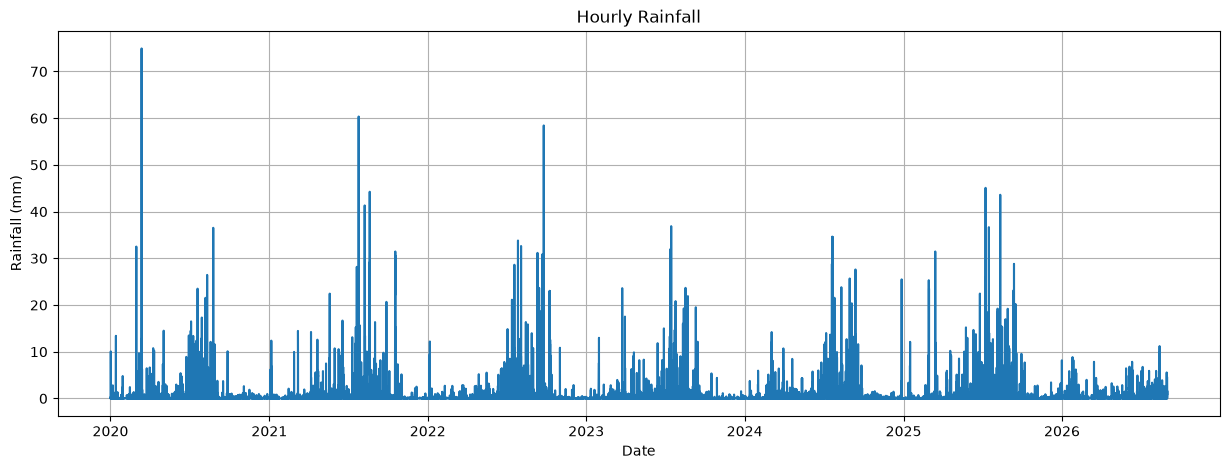

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    hourly_rainfall.index,
    hourly_rainfall["rainfall"]
)

plt.title("Hourly Rainfall")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.grid(True)

plt.show()

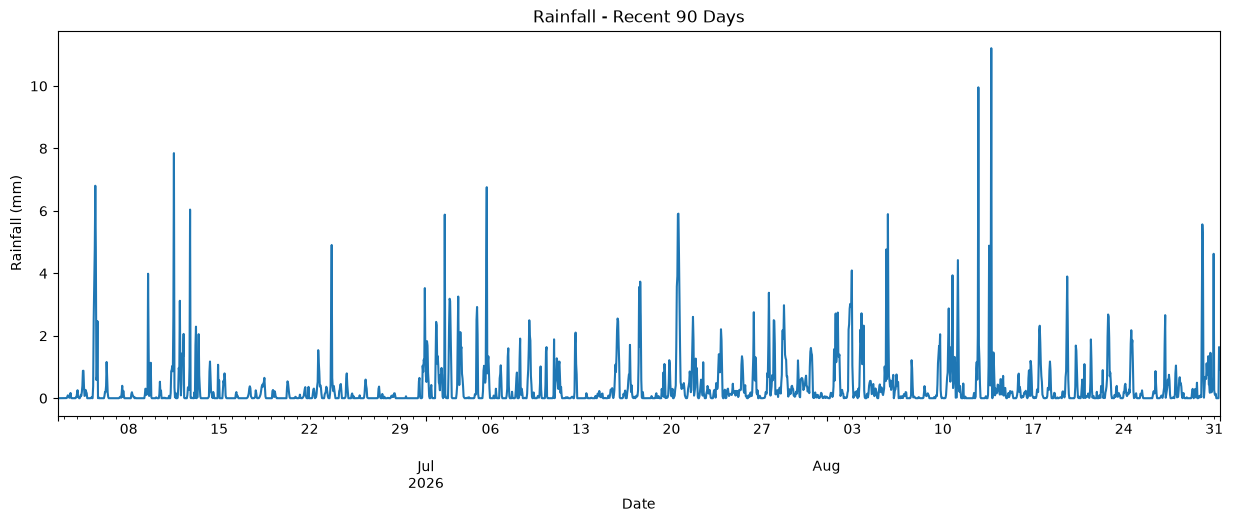

In [13]:
plt.figure(figsize=(15, 5))

hourly_rainfall["rainfall"].tail(24 * 90).plot()

plt.title("Rainfall - Recent 90 Days")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")

plt.show()

In [14]:
df = hourly_rainfall.copy()

# Lag features
for lag in [1, 2, 3, 6, 12, 24, 48]:
    df[f"lag_{lag}"] = df["rainfall"].shift(lag)

# Rolling rainfall
df["rolling_3h"] = df["rainfall"].rolling(3).sum()
df["rolling_6h"] = df["rainfall"].rolling(6).sum()
df["rolling_12h"] = df["rainfall"].rolling(12).sum()
df["rolling_24h"] = df["rainfall"].rolling(24).sum()

# Time features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

# Target = next hour rainfall
df["target"] = df["rainfall"].shift(-1)

df = df.dropna()

print(df.head())
print("Final shape:", df.shape)

                     rainfall     lag_1     lag_2     lag_3     lag_6  \
datetime                                                                
2020-01-03 00:00:00       0.0  0.015705  0.044617  0.069866  0.000000   
2020-01-03 01:00:00       0.0  0.000000  0.015705  0.044617  0.000000   
2020-01-03 02:00:00       0.0  0.000000  0.000000  0.015705  0.002336   
2020-01-03 03:00:00       0.0  0.000000  0.000000  0.000000  0.069866   
2020-01-03 04:00:00       0.0  0.000000  0.000000  0.000000  0.044617   

                       lag_12    lag_24    lag_48  rolling_3h  rolling_6h  \
datetime                                                                    
2020-01-03 00:00:00  0.194134  0.000000  0.186617    0.060322    0.132523   
2020-01-03 01:00:00  0.174980  0.000000  0.000000    0.015705    0.132523   
2020-01-03 02:00:00  0.009101  0.023463  0.000000    0.000000    0.130188   
2020-01-03 03:00:00  0.000805  0.000000  0.000000    0.000000    0.060322   
2020-01-03 04:00:00  0.000

In [16]:
feature_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",
    "lag_48",
    "rolling_3h",
    "rolling_6h",
    "rolling_12h",
    "rolling_24h",
    "hour",
    "dayofweek",
    "month"
]

X = df[feature_columns].values
y = df["target"].values

print("X:", X.shape)
print("y:", y.shape)

X: (58379, 14)
y: (58379,)


In [17]:
split_index = int(len(X) * 0.80)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (46703, 14)
Testing : (11676, 14)


In [18]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, 1)
).ravel()

print(
    np.isfinite(X_train_scaled).all(),
    np.isfinite(y_train_scaled).all()
)

True True


In [19]:
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, 1)
).ravel()

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, 1)
).ravel()

print(
    np.isfinite(X_train_scaled).all(),
    np.isfinite(y_train_scaled).all()
)

True True


In [20]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    device="cuda",
    random_state=42
)

xgb_model.fit(
    X_train_scaled,
    y_train_scaled,
    eval_set=[
        (X_test_scaled, y_test_scaled)
    ],
    verbose=False
)

print("XGBoost GPU training completed.")

XGBoost GPU training completed.


In [21]:
xgb_pred_scaled = xgb_model.predict(X_test_scaled)

xgb_pred = y_scaler.inverse_transform(
    xgb_pred_scaled.reshape(-1, 1)
).ravel()

# Rainfall cannot be negative
xgb_pred = np.clip(xgb_pred, 0, None)

print(xgb_pred[:10])

[0.0537149  0.03675357 0.07714644 0.11415753 0.40395737 0.13934678
 0.05217308 0.06608284 0.07549393 0.287519  ]


C:\Users\HP\miniconda3\envs\pytorch_gpu\Lib\site-packages\xgboost\core.py:751: UserWarning: [10:34:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    # Avoid division by zero in rainfall data
    mask = y_true != 0

    if mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return mae, rmse, mape, r2


xgb_metrics = calculate_metrics(
    y_test,
    xgb_pred
)

print("XGBoost")
print("MAE  :", xgb_metrics[0])
print("RMSE :", xgb_metrics[1])
print("MAPE :", xgb_metrics[2])
print("R2   :", xgb_metrics[3])

XGBoost
MAE  : 0.36024963348919253
RMSE : 1.2880592893664415
MAPE : 2677.7237238720386
R2   : 0.3516221371483219


In [23]:
sequence_length = 24

rainfall_values = hourly_rainfall["rainfall"].values

# Scale rainfall
rainfall_scaler = StandardScaler()

rainfall_scaled = rainfall_scaler.fit_transform(
    rainfall_values.reshape(-1, 1)
).flatten()

X_seq = []
y_seq = []

for i in range(
    sequence_length,
    len(rainfall_scaled)
):

    X_seq.append(
        rainfall_scaled[
            i-sequence_length:i
        ]
    )

    y_seq.append(
        rainfall_scaled[i]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)

Sequence shape: (58404, 24)
Target shape: (58404,)


In [24]:
X_seq = X_seq.reshape(
    X_seq.shape[0],
    X_seq.shape[1],
    1
)

print(X_seq.shape)

(58404, 24, 1)


In [25]:
split = int(len(X_seq) * 0.80)

X_train_seq = X_seq[:split]
X_test_seq = X_seq[split:]

y_train_seq = y_seq[:split]
y_test_seq = y_seq[split:]

print(X_train_seq.shape)
print(X_test_seq.shape)

(46723, 24, 1)
(11681, 24, 1)


In [26]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
).reshape(-1, 1)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
).reshape(-1, 1)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset))

Training samples: 46723


In [27]:
import torch.nn as nn

class RainfallLSTM(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)

In [28]:
lstm_model = RainfallLSTM().to(device)

print(lstm_model)

RainfallLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [29]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

epochs = 50

for epoch in range(epochs):

    lstm_model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = lstm_model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        # Safety check against NaN
        if not torch.isfinite(loss):
            print("NaN/Inf loss detected!")
            break

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.6f}"
        )

Epoch [5/50] Loss: 0.534406
Epoch [10/50] Loss: 0.527228
Epoch [15/50] Loss: 0.520656
Epoch [20/50] Loss: 0.511058
Epoch [25/50] Loss: 0.496092
Epoch [30/50] Loss: 0.480249
Epoch [35/50] Loss: 0.452903
Epoch [40/50] Loss: 0.435857
Epoch [45/50] Loss: 0.415605
Epoch [50/50] Loss: 0.389759


In [30]:
lstm_model.eval()

with torch.no_grad():

    X_test_gpu = X_test_tensor.to(device)

    lstm_pred_scaled = lstm_model(
        X_test_gpu
    )

    lstm_pred_scaled = (
        lstm_pred_scaled
        .cpu()
        .numpy()
        .flatten()
    )

lstm_pred = rainfall_scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).flatten()

lstm_actual = rainfall_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

lstm_pred = np.clip(
    lstm_pred,
    0,
    None
)

print(lstm_pred[:10])

[1.7348578  0.05315661 0.3977576  0.55585    0.08143869 0.14733219
 0.08994231 0.11034559 0.09060013 0.4146185 ]


In [31]:
lstm_metrics = calculate_metrics(
    lstm_actual,
    lstm_pred
)

print("LSTM")
print("MAE  :", lstm_metrics[0])
print("RMSE :", lstm_metrics[1])
print("MAPE :", lstm_metrics[2])
print("R2   :", lstm_metrics[3])

LSTM
MAE  : 0.31493757253780447
RMSE : 1.202893620680103
MAPE : 1856.2785260936807
R2   : 0.4342900210177214


In [32]:
class RainfallGRU(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2
    ):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, _ = self.gru(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)

In [33]:
gru_model = RainfallGRU().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

epochs = 50

for epoch in range(epochs):

    gru_model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = gru_model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        if not torch.isfinite(loss):
            print("NaN/Inf loss detected!")
            break

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            gru_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.6f}"
        )

Epoch [5/50] Loss: 0.537600
Epoch [10/50] Loss: 0.532514
Epoch [15/50] Loss: 0.526874
Epoch [20/50] Loss: 0.523595
Epoch [25/50] Loss: 0.514737
Epoch [30/50] Loss: 0.497431
Epoch [35/50] Loss: 0.481145
Epoch [40/50] Loss: 0.461562
Epoch [45/50] Loss: 0.442201
Epoch [50/50] Loss: 0.419707


In [34]:
gru_model.eval()

with torch.no_grad():

    X_test_gpu = X_test_tensor.to(device)

    gru_pred_scaled = gru_model(
        X_test_gpu
    )

    gru_pred_scaled = (
        gru_pred_scaled
        .cpu()
        .numpy()
        .flatten()
    )

gru_pred = rainfall_scaler.inverse_transform(
    gru_pred_scaled.reshape(-1, 1)
).flatten()

gru_actual = rainfall_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

gru_pred = np.clip(
    gru_pred,
    0,
    None
)

In [35]:
gru_metrics = calculate_metrics(
    gru_actual,
    gru_pred
)

print("GRU")
print("MAE  :", gru_metrics[0])
print("RMSE :", gru_metrics[1])
print("MAPE :", gru_metrics[2])
print("R2   :", gru_metrics[3])


GRU
MAE  : 0.3401740085862212
RMSE : 1.2419380630371404
MAPE : 2045.043326883414
R2   : 0.39696950964256594


In [36]:
results = pd.DataFrame({

    "Model": [
        "XGBoost",
        "LSTM",
        "GRU"
    ],

    "MAE": [
        xgb_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],

    "RMSE": [
        xgb_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],

    "MAPE": [
        xgb_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ],

    "R2": [
        xgb_metrics[3],
        lstm_metrics[3],
        gru_metrics[3]
    ]
})

results

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,0.360250,1.288059,2677.723724,0.351622
1,LSTM,0.314938,1.202894,1856.278526,0.434290
2,GRU,0.340174,1.241938,2045.043327,0.396970


In [37]:
results["MAE_rank"] = results["MAE"].rank()
results["RMSE_rank"] = results["RMSE"].rank()
results["MAPE_rank"] = results["MAPE"].rank()
results["R2_rank"] = results["R2"].rank(
    ascending=False
)

results["Total_rank"] = (
    results["MAE_rank"]
    + results["RMSE_rank"]
    + results["MAPE_rank"]
    + results["R2_rank"]
)

results = results.sort_values(
    "Total_rank"
)

print(results)

best_model = results.iloc[0]["Model"]

print("\nBEST RAINFALL FORECASTING MODEL:")
print(best_model)

     Model       MAE      RMSE         MAPE        R2  MAE_rank  RMSE_rank  \
1     LSTM  0.314938  1.202894  1856.278526  0.434290       1.0        1.0   
2      GRU  0.340174  1.241938  2045.043327  0.396970       2.0        2.0   
0  XGBoost  0.360250  1.288059  2677.723724  0.351622       3.0        3.0   

   MAPE_rank  R2_rank  Total_rank  
1        1.0      1.0         4.0  
2        2.0      2.0         8.0  
0        3.0      3.0        12.0  

BEST RAINFALL FORECASTING MODEL:
LSTM


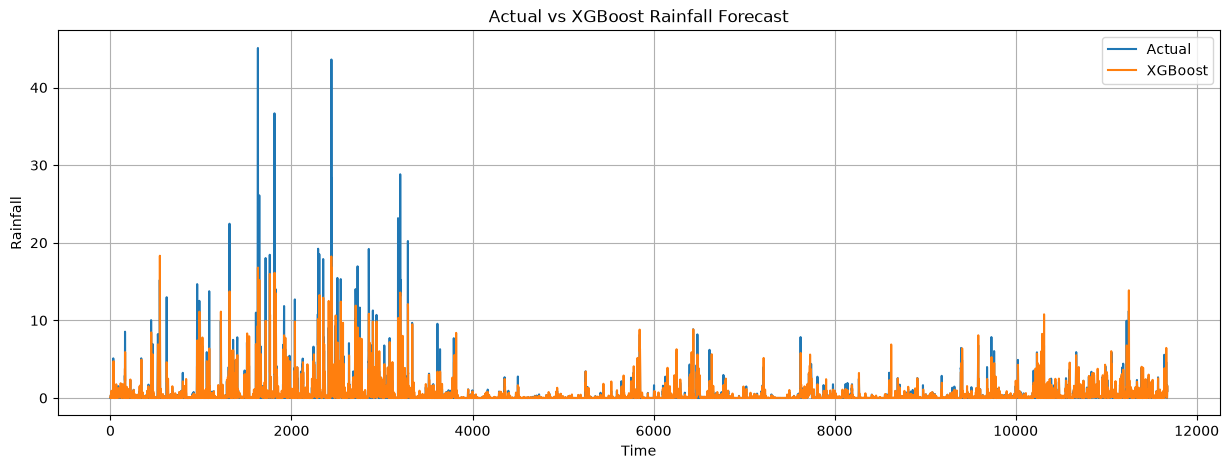

In [38]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    xgb_pred,
    label="XGBoost"
)

plt.title("Actual vs XGBoost Rainfall Forecast")
plt.xlabel("Time")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(True)

plt.show()

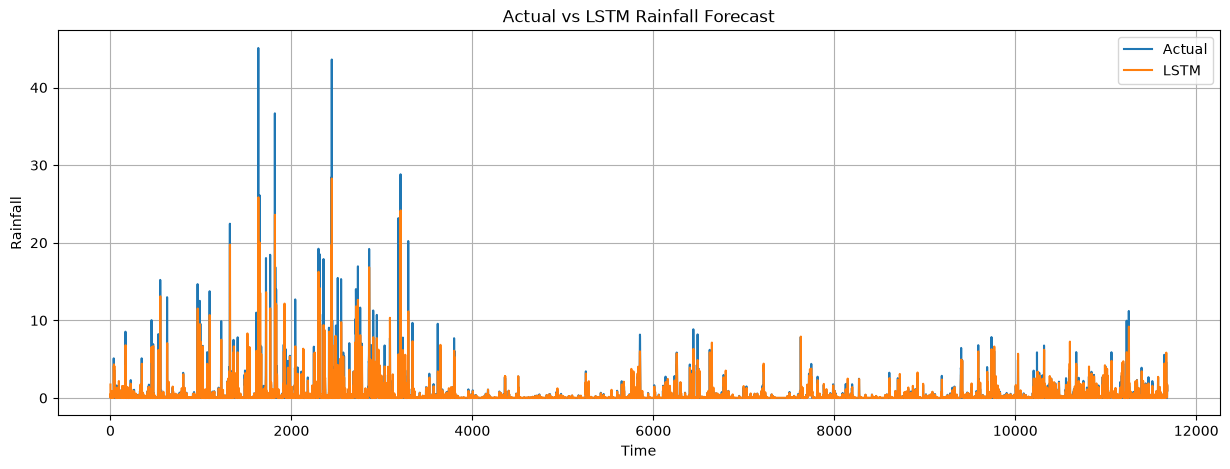

In [39]:
plt.figure(figsize=(15, 5))

plt.plot(
    lstm_actual,
    label="Actual"
)

plt.plot(
    lstm_pred,
    label="LSTM"
)

plt.title("Actual vs LSTM Rainfall Forecast")
plt.xlabel("Time")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(True)

plt.show()

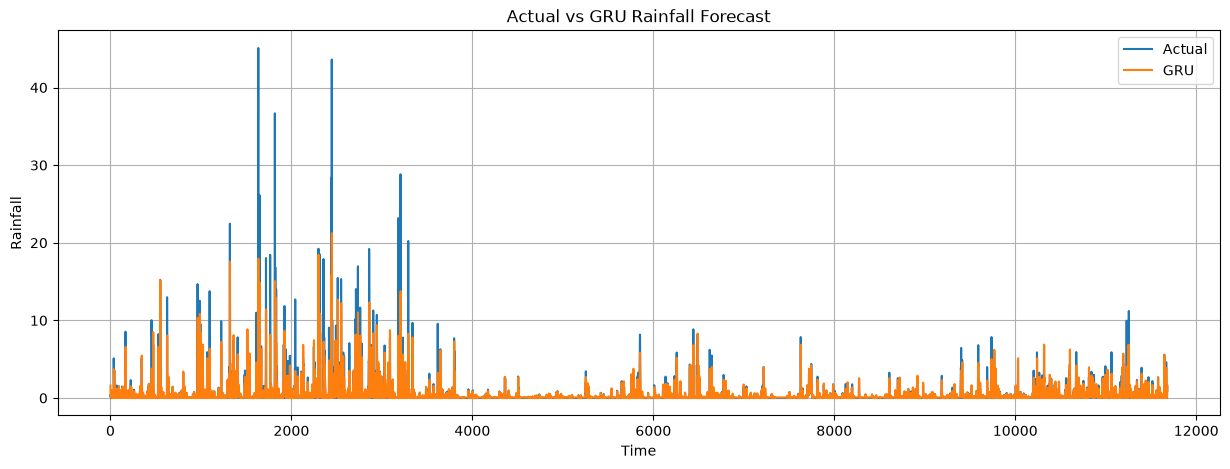

In [40]:
plt.figure(figsize=(15, 5))

plt.plot(
    gru_actual,
    label="Actual"
)

plt.plot(
    gru_pred,
    label="GRU"
)

plt.title("Actual vs GRU Rainfall Forecast")
plt.xlabel("Time")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(True)

plt.show()

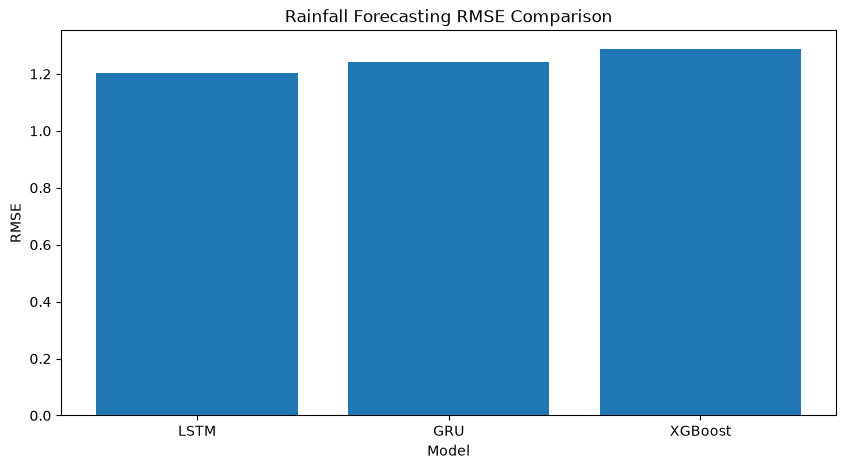

In [41]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Rainfall Forecasting RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()

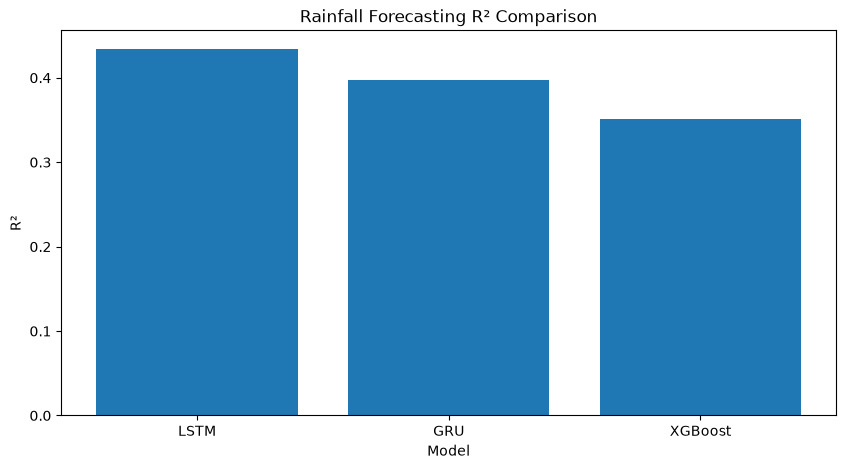

In [42]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["R2"]
)

plt.title("Rainfall Forecasting R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")

plt.show()

In [43]:
def forecast_next_hours(
    model,
    recent_values,
    hours=24
):

    model.eval()

    sequence = recent_values.copy()

    forecasts = []

    for _ in range(hours):

        input_data = np.array(
            sequence[-24:]
        )

        input_scaled = rainfall_scaler.transform(
            input_data.reshape(-1, 1)
        )

        tensor = torch.tensor(
            input_scaled,
            dtype=torch.float32
        ).reshape(1, 24, 1)

        tensor = tensor.to(device)

        with torch.no_grad():

            prediction = model(
                tensor
            )

        prediction = prediction.cpu().numpy()[0][0]

        prediction_original = (
            rainfall_scaler.inverse_transform(
                [[prediction]]
            )[0][0]
        )

        prediction_original = max(
            0,
            prediction_original
        )

        forecasts.append(
            prediction_original
        )

        sequence = np.append(
            sequence,
            prediction_original
        )

    return np.array(forecasts)

In [44]:
recent_values = hourly_rainfall[
    "rainfall"
].values[-24:]

future_forecast = forecast_next_hours(
    lstm_model,
    recent_values,
    hours=24
)

print("Next 24-hour rainfall forecast:")
print(future_forecast)

Next 24-hour rainfall forecast:
[0.48730077 0.36183695 0.30907439 0.28166016 0.27995474 0.29479765
 0.25407984 0.1282243  0.         0.         0.         0.
 0.         0.02744982 0.06356085 0.10651699 0.13666397 0.18180171
 0.27466541 0.36337427 0.43487751 0.52315781 0.52560177 0.43571599]


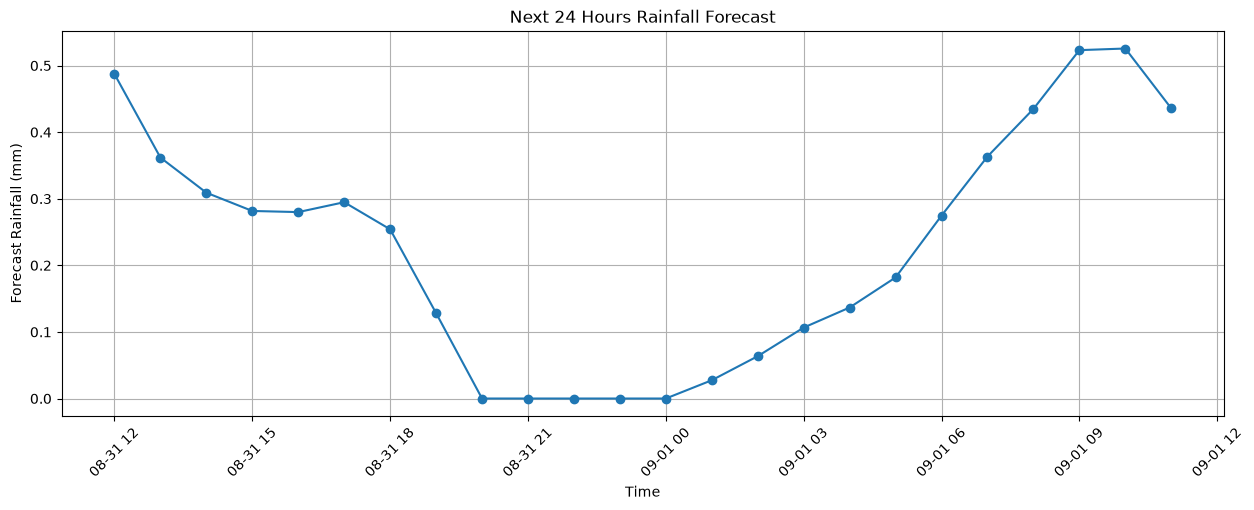

In [45]:
last_time = hourly_rainfall.index[-1]

future_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,
    freq="1h"
)

plt.figure(figsize=(15, 5))

plt.plot(
    future_times,
    future_forecast,
    marker="o"
)

plt.title(
    "Next 24 Hours Rainfall Forecast"
)

plt.xlabel("Time")
plt.ylabel("Forecast Rainfall (mm)")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [46]:
max_rainfall = future_forecast.max()

total_24h_rainfall = future_forecast.sum()

print("Maximum hourly rainfall:",
      max_rainfall)

print("Forecasted 24-hour rainfall:",
      total_24h_rainfall)

Maximum hourly rainfall: 0.5256017723009826
Forecasted 24-hour rainfall: 5.470314899956703


In [47]:
rainfall_risk_score = min(
    total_24h_rainfall / 200,
    1.0
)
print(
    "Rainfall Risk Score:",
    rainfall_risk_score
)

Rainfall Risk Score: 0.027351574499783517


In [56]:
import os

MODEL_DIR = r"E:\MY projects\Flash Flood Prediction Project\models\Rainfall"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model folder:", MODEL_DIR)

Model folder: E:\MY projects\Flash Flood Prediction Project\models\Rainfall


In [61]:
import os
import zipfile
import glob
import pandas as pd
import numpy as np

DATA_ZIP = r"E:\MY projects\Flash Flood Prediction Project\data\rainfall_monthly.zip"

EXTRACT_DIR = r"E:\MY projects\Flash Flood Prediction Project\data\rainfall_extracted"

os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(DATA_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("✅ ZIP extracted")

✅ ZIP extracted


In [62]:
csv_files = glob.glob(
    os.path.join(EXTRACT_DIR, "**", "*.csv"),
    recursive=True
)

print("Number of CSV files:", len(csv_files))

data_list = []

for file in csv_files:
    try:
        if os.path.getsize(file) == 0:
            continue

        temp = pd.read_csv(file)

        if temp.empty:
            continue

        data_list.append(temp)

    except Exception as e:
        print("Skipped:", file)
        print("Reason:", e)

if len(data_list) == 0:
    raise ValueError("❌ No valid CSV files found!")

df = pd.concat(data_list, ignore_index=True)

print("✅ Data loaded")
print("Shape:", df.shape)
print(df.head())

Number of CSV files: 80
✅ Data loaded
Shape: (116843, 4)
              datetime  rainfall_mm_per_hour  year  month
0  2020-01-01 00:00:00              0.186617  2020      1
1  2020-01-01 00:30:00              0.000000  2020      1
2  2020-01-01 01:00:00              0.000000  2020      1
3  2020-01-01 01:30:00              0.000000  2020      1
4  2020-01-01 02:00:00              0.000000  2020      1


In [63]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    errors="coerce"
)

df["rainfall_mm_per_hour"] = pd.to_numeric(
    df["rainfall_mm_per_hour"],
    errors="coerce"
)

df = df.dropna(
    subset=["datetime", "rainfall_mm_per_hour"]
)

df = df[
    np.isfinite(df["rainfall_mm_per_hour"])
]

df = df.sort_values("datetime")

df = df.drop_duplicates(
    subset=["datetime"]
)

# Rainfall cannot be negative
df.loc[
    df["rainfall_mm_per_hour"] < 0,
    "rainfall_mm_per_hour"
] = 0

print("✅ Cleaning completed")
print(df.shape)

✅ Cleaning completed
(116843, 4)


In [64]:
hourly = (
    df.set_index("datetime")[
        "rainfall_mm_per_hour"
    ]
    .resample("1h")
    .sum()
    .to_frame()
)

# Missing hours = no recorded rainfall
hourly["rainfall_mm_per_hour"] = (
    hourly["rainfall_mm_per_hour"]
    .fillna(0)
)

print("✅ Hourly rainfall created")
print(hourly.head())
print()
print("Shape:", hourly.shape)

✅ Hourly rainfall created
                     rainfall_mm_per_hour
datetime                                 
2020-01-01 00:00:00              0.186617
2020-01-01 01:00:00              0.000000
2020-01-01 02:00:00              0.000000
2020-01-01 03:00:00              0.000000
2020-01-01 04:00:00              0.033584

Shape: (58428, 1)


In [65]:
print(hourly["rainfall_mm_per_hour"].describe())

count    58428.000000
mean         0.350133
std          1.701805
min          0.000000
25%          0.000000
50%          0.000000
75%          0.099819
max         74.934643
Name: rainfall_mm_per_hour, dtype: float64


In [66]:
from sklearn.preprocessing import StandardScaler

train_size = int(len(hourly) * 0.8)

train_values = (
    hourly["rainfall_mm_per_hour"]
    .values[:train_size]
    .reshape(-1, 1)
)

scaler = StandardScaler()

scaler.fit(train_values)

rainfall_values = (
    hourly["rainfall_mm_per_hour"]
    .values
    .reshape(-1, 1)
)

rainfall_scaled = scaler.transform(
    rainfall_values
)

print("✅ Scaler created")
print("Scaled shape:", rainfall_scaled.shape)

✅ Scaler created
Scaled shape: (58428, 1)


In [67]:
import torch

MODEL_DIR = r"E:\MY projects\Flash Flood Prediction Project\models\Rainfall"

os.makedirs(MODEL_DIR, exist_ok=True)

lstm_checkpoint = {
    "model_type": "LSTM",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "sequence_length": 24,

    "model_state_dict": lstm_model.state_dict(),

    "scaler": scaler,

    "historical_min": float(
        hourly["rainfall_mm_per_hour"].min()
    ),

    "historical_max": float(
        hourly["rainfall_mm_per_hour"].max()
    ),

    "metrics": {
        "MAE": float(lstm_metrics[0]),
        "RMSE": float(lstm_metrics[1]),
        "MAPE": float(lstm_metrics[2]),
        "R2": float(lstm_metrics[3])
    }
}

lstm_path = os.path.join(
    MODEL_DIR,
    "Rainfall_LSTM.pt"
)

torch.save(
    lstm_checkpoint,
    lstm_path
)

print("✅ LSTM saved successfully!")
print(lstm_path)

✅ LSTM saved successfully!
E:\MY projects\Flash Flood Prediction Project\models\Rainfall\Rainfall_LSTM.pt


In [68]:
gru_checkpoint = {
    "model_type": "GRU",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "sequence_length": 24,

    "model_state_dict": gru_model.state_dict(),

    "scaler": scaler,

    "historical_min": float(
        hourly["rainfall_mm_per_hour"].min()
    ),

    "historical_max": float(
        hourly["rainfall_mm_per_hour"].max()
    ),

    "metrics": {
        "MAE": float(gru_metrics[0]),
        "RMSE": float(gru_metrics[1]),
        "MAPE": float(gru_metrics[2]),
        "R2": float(gru_metrics[3])
    }
}

gru_path = os.path.join(
    MODEL_DIR,
    "Rainfall_GRU.pt"
)

torch.save(
    gru_checkpoint,
    gru_path
)

print("✅ GRU saved successfully!")
print(gru_path)

✅ GRU saved successfully!
E:\MY projects\Flash Flood Prediction Project\models\Rainfall\Rainfall_GRU.pt


In [69]:
import joblib

scaler_path = os.path.join(
    MODEL_DIR,
    "Rainfall_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("✅ Scaler saved!")

✅ Scaler saved!


In [71]:
import torch
import os

MODEL_DIR = r"E:\MY projects\Flash Flood Prediction Project\models\Rainfall"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save only the trained XGBoost model
checkpoint = {
    "model_type": "XGBoost",
    "model": xgb_model
}

save_path = os.path.join(
    MODEL_DIR,
    "Rainfall_XGBoost.pt"
)

torch.save(checkpoint, save_path)

print("✅ XGBoost model saved successfully!")
print("📁 Path:", save_path)

✅ XGBoost model saved successfully!
📁 Path: E:\MY projects\Flash Flood Prediction Project\models\Rainfall\Rainfall_XGBoost.pt


In [73]:
import os
import torch

MODEL_DIR = r"E:\MY projects\Flash Flood Prediction Project\models\Rainfall"

os.makedirs(MODEL_DIR, exist_ok=True)

# Sort models by performance
results = results.copy()

results["MAE_Rank"] = results["MAE"].rank(ascending=True)
results["RMSE_Rank"] = results["RMSE"].rank(ascending=True)
results["MAPE_Rank"] = results["MAPE"].rank(ascending=True)
results["R2_Rank"] = results["R2"].rank(ascending=False)

results["Total_Rank"] = (
    results["MAE_Rank"]
    + results["RMSE_Rank"]
    + results["MAPE_Rank"]
    + results["R2_Rank"]
)

results = results.sort_values(
    "Total_Rank"
).reset_index(drop=True)

best_model_name = results.loc[0, "Model"]

print("🏆 BEST MODEL:", best_model_name)
print()
print(results)

🏆 BEST MODEL: LSTM

     Model       MAE      RMSE         MAPE        R2  MAE_rank  RMSE_rank  \
0     LSTM  0.314938  1.202894  1856.278526  0.434290       1.0        1.0   
1      GRU  0.340174  1.241938  2045.043327  0.396970       2.0        2.0   
2  XGBoost  0.360250  1.288059  2677.723724  0.351622       3.0        3.0   

   MAPE_rank  R2_rank  Total_rank  MAE_Rank  RMSE_Rank  MAPE_Rank  R2_Rank  \
0        1.0      1.0         4.0       1.0        1.0        1.0      1.0   
1        2.0      2.0         8.0       2.0        2.0        2.0      2.0   
2        3.0      3.0        12.0       3.0        3.0        3.0      3.0   

   Total_Rank  
0         4.0  
1         8.0  
2        12.0  


In [74]:
best_model_path = os.path.join(
    MODEL_DIR,
    "Rainfall_Best_Model.pt"
)

if best_model_name == "LSTM":

    checkpoint = {
        "model_type": "LSTM",
        "model_state_dict": lstm_model.state_dict(),
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "sequence_length": 24,
        "scaler": scaler
    }

    torch.save(checkpoint, best_model_path)


elif best_model_name == "GRU":

    checkpoint = {
        "model_type": "GRU",
        "model_state_dict": gru_model.state_dict(),
        "input_size": 1,
        "hidden_size": 64,
        "num_layers": 2,
        "sequence_length": 24,
        "scaler": scaler
    }

    torch.save(checkpoint, best_model_path)


elif best_model_name == "XGBoost":

    checkpoint = {
        "model_type": "XGBoost",
        "model": xgb_model
    }

    torch.save(checkpoint, best_model_path)


print("✅ Best model saved successfully!")
print("🏆 Best model:", best_model_name)
print("📁 Saved at:", best_model_path)

✅ Best model saved successfully!
🏆 Best model: LSTM
📁 Saved at: E:\MY projects\Flash Flood Prediction Project\models\Rainfall\Rainfall_Best_Model.pt
